# Support Vector Machine - Diabetes Classification

This notebook implements the Support Vector Machine (SVM) algorithm for the diabetes classification problem.


In [1]:
# Importing libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

In [2]:
# Load the dataset

df = pd.read_csv("../dataset/diabetes_prediction_dataset_2000.csv")
df.head()


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,13.0,0,0,No Info,20.82,5.8,126,0
1,Female,3.0,0,0,No Info,21.00,5.0,145,0
2,Male,63.0,0,0,former,25.32,3.5,200,0
3,Female,2.0,0,0,never,17.43,6.1,126,0
4,Female,33.0,0,0,not current,40.08,6.2,200,1


In [3]:
# Basic dataset checking

print("Dataset shape:", df.shape)
print("\nDataset information:")
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())


Dataset shape: (2000, 9)

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               2000 non-null   object 
 1   age                  2000 non-null   float64
 2   hypertension         2000 non-null   int64  
 3   heart_disease        2000 non-null   int64  
 4   smoking_history      2000 non-null   object 
 5   bmi                  2000 non-null   float64
 6   HbA1c_level          2000 non-null   float64
 7   blood_glucose_level  2000 non-null   int64  
 8   diabetes             2000 non-null   int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 140.8+ KB
None

Missing values:
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes   

In [4]:
# Removing duplicates

before = len(df)
df = df.drop_duplicates()
after = len(df)

print("Rows before removing duplicates:", before)
print("Rows after removing duplicates:", after)
print("Duplicates removed:", before - after)


Rows before removing duplicates: 2000
Rows after removing duplicates: 1996
Duplicates removed: 4


In [5]:
# Checking missing values

print("Missing values before treatment:")
print(df.isnull().sum())

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

print("\nMissing values after treatment:")
print(df.isnull().sum())


Missing values before treatment:
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

Missing values after treatment:
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64


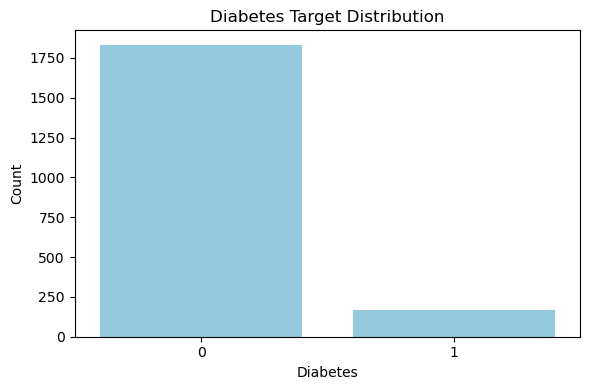

In [6]:
# Diabetes class distribution

plt.figure(figsize=(6, 4))
sns.countplot(x=df["diabetes"], color="skyblue")
plt.title("Diabetes Target Distribution")
plt.xlabel("Diabetes")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


### Insight

The target variable contains two classes, 0 for patients without diabetes and 1 for patients with diabetes. The classes are not equally distributed, so a stratified train-test split is used to maintain a similar class proportion in both sets.


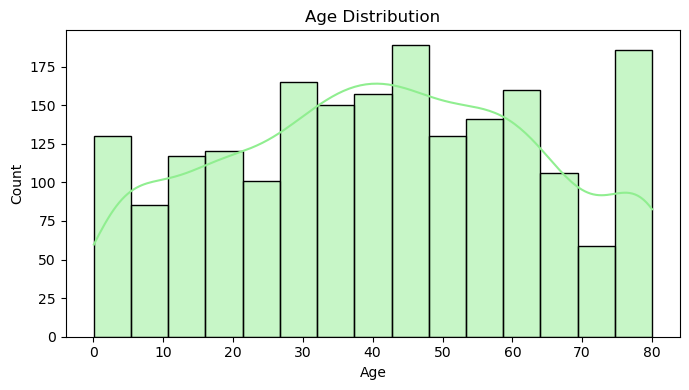

In [7]:
# Age distribution

plt.figure(figsize=(7, 4))
sns.histplot(df["age"], kde=True, color="lightgreen")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


### Insight

The age distribution contains patients from different age groups, with more observations concentrated in the middle age ranges.


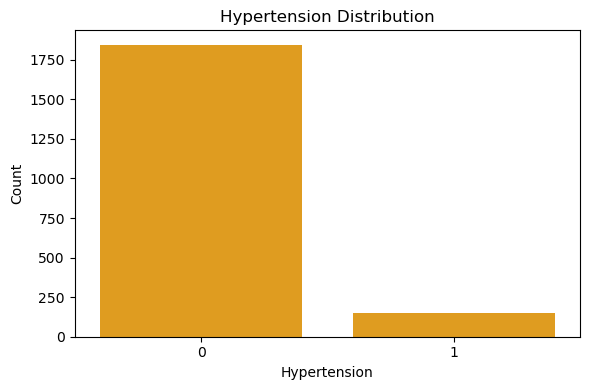

In [8]:
# Hypertension distribution

plt.figure(figsize=(6, 4))
sns.countplot(x=df["hypertension"], color="orange")
plt.title("Hypertension Distribution")
plt.xlabel("Hypertension")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


### Insight

Hypertension is a binary feature with values 0 and 1. Most observations have a value of 0, so the feature is imbalanced toward patients without hypertension.


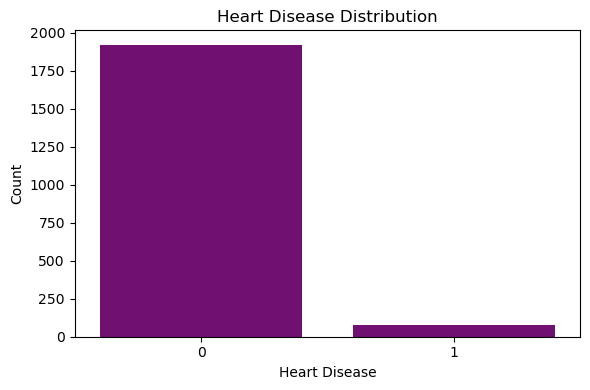

In [9]:
# Heart disease distribution

plt.figure(figsize=(6, 4))
sns.countplot(x=df["heart_disease"], color="purple")
plt.title("Heart Disease Distribution")
plt.xlabel("Heart Disease")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


### Insight

Heart disease is a binary feature, and most observations have a value of 0. This shows that heart disease is less common in this dataset than its absence.


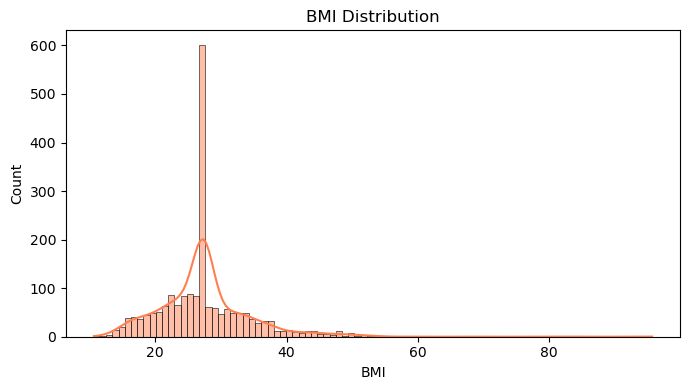

In [10]:
# BMI distribution

plt.figure(figsize=(7, 4))
sns.histplot(df["bmi"], kde=True, color="coral")
plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


### Insight

The BMI values are spread across a wide range, with most observations concentrated around the middle of the distribution and fewer observations at higher values.


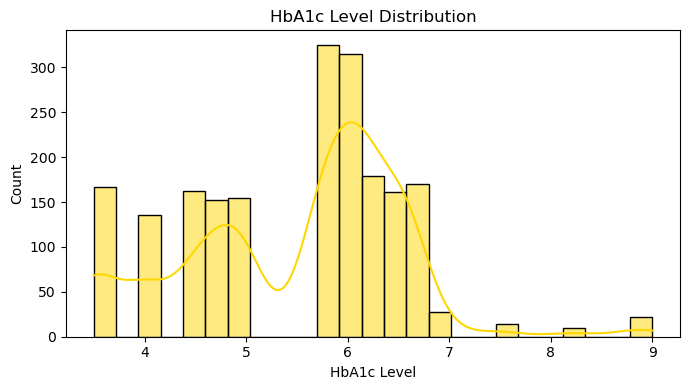

In [11]:
# HbA1c level distribution

plt.figure(figsize=(7, 4))
sns.histplot(df["HbA1c_level"], kde=True, color="gold")
plt.title("HbA1c Level Distribution")
plt.xlabel("HbA1c Level")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


### Insight

The HbA1c level distribution shows that most observations are concentrated in a lower range, while some patients have higher HbA1c values.


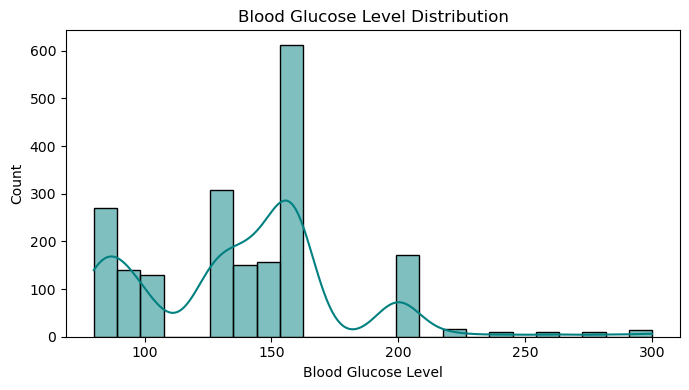

In [12]:
# Blood glucose level distribution

plt.figure(figsize=(7, 4))
sns.histplot(df["blood_glucose_level"], kde=True, color="teal")
plt.title("Blood Glucose Level Distribution")
plt.xlabel("Blood Glucose Level")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


### Insight

The blood glucose level distribution has a wider spread, with a smaller number of observations having higher glucose levels. These higher values are useful to examine in relation to diabetes.


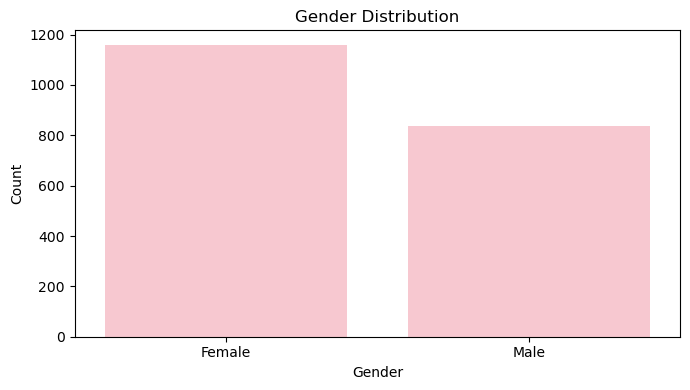

In [13]:
# Gender distribution

plt.figure(figsize=(7, 4))
sns.countplot(x=df["gender"], color="pink")
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


### Insight

The gender categories have different frequencies, but the main categories are represented in the dataset.


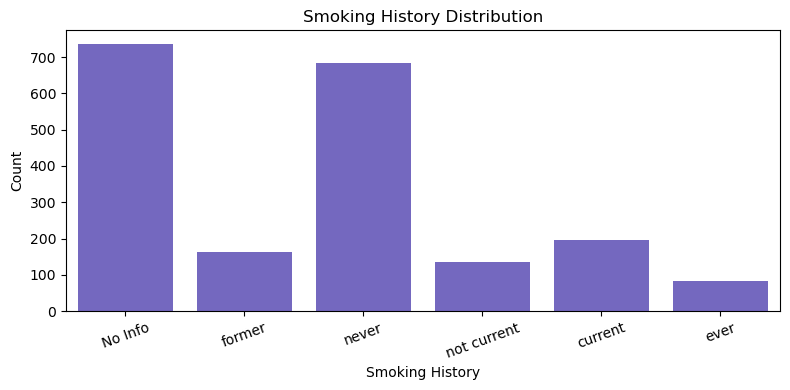

In [14]:
# Smoking history distribution

plt.figure(figsize=(8, 4))
sns.countplot(x=df["smoking_history"], color="slateblue")
plt.title("Smoking History Distribution")
plt.xlabel("Smoking History")
plt.ylabel("Count")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


### Insight

The smoking history categories are not evenly distributed. Some categories contain more patients than others.


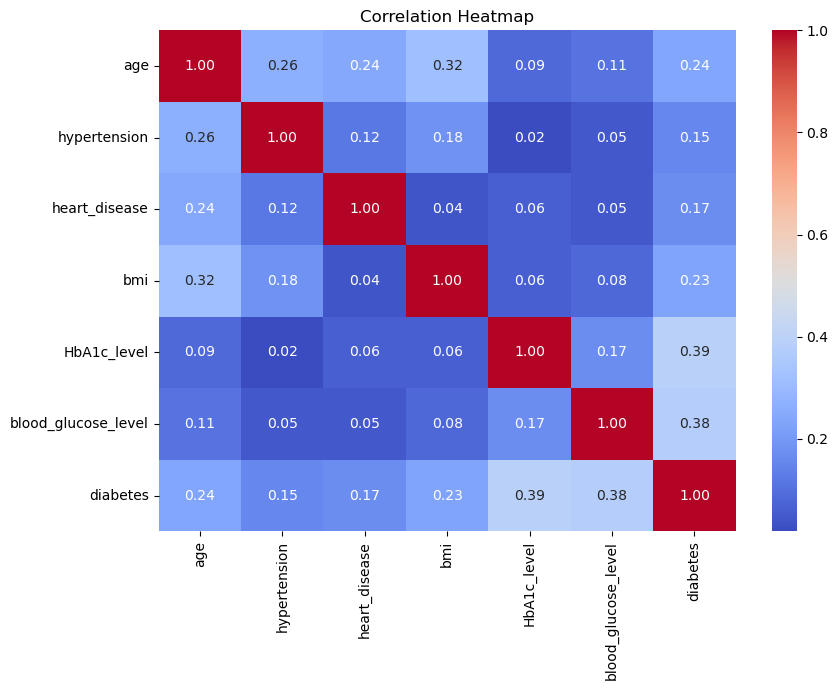

In [15]:
# Correlation heatmap

plt.figure(figsize=(9, 7))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


### Insight

The correlation heatmap shows the relationships among the numerical variables. Blood glucose level and HbA1c level show noticeable relationships with the diabetes target compared with several other numerical features.


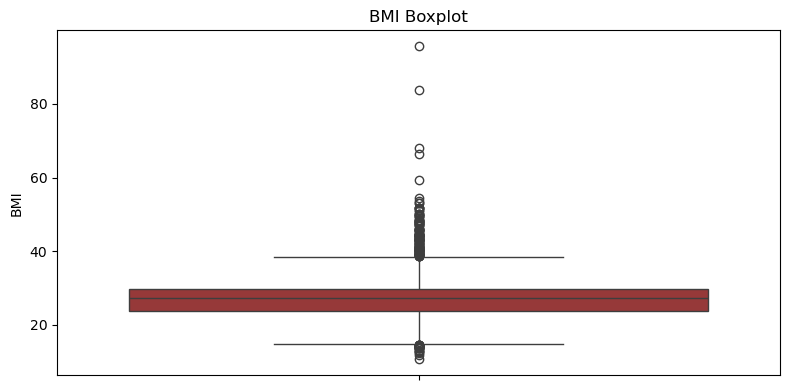

In [16]:
# BMI boxplot

plt.figure(figsize=(8, 4))
sns.boxplot(y=df["bmi"], color="brown")
plt.title("BMI Boxplot")
plt.ylabel("BMI")
plt.tight_layout()
plt.show()


### Insight

The BMI boxplot shows the spread of the feature and highlights observations that are far from the main range. These values are checked using the IQR method before model training.


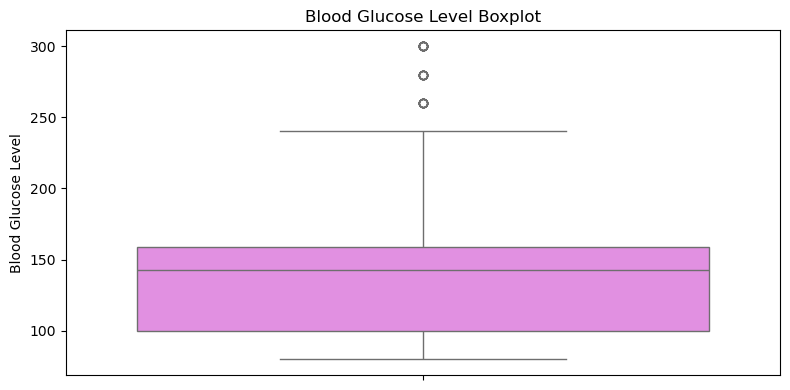

In [17]:
# Blood glucose level boxplot

plt.figure(figsize=(8, 4))
sns.boxplot(y=df["blood_glucose_level"], color="violet")
plt.title("Blood Glucose Level Boxplot")
plt.ylabel("Blood Glucose Level")
plt.tight_layout()
plt.show()


### Insight

The blood glucose boxplot shows a wider spread and some high-value observations. These observations are considered during the outlier treatment step.


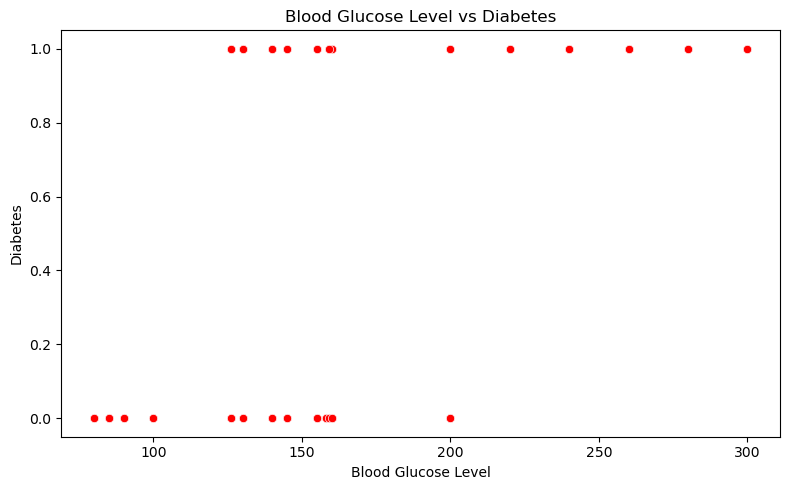

In [18]:
# Blood glucose level vs diabetes

plt.figure(figsize=(8, 5))
sns.scatterplot(
    x=df["blood_glucose_level"],
    y=df["diabetes"],
    color="red"
)
plt.title("Blood Glucose Level vs Diabetes")
plt.xlabel("Blood Glucose Level")
plt.ylabel("Diabetes")
plt.tight_layout()
plt.show()


### Insight

The scatter plot shows that diabetes-positive observations appear more frequently at higher blood glucose levels. This suggests that blood glucose level is an important feature for the classification problem.


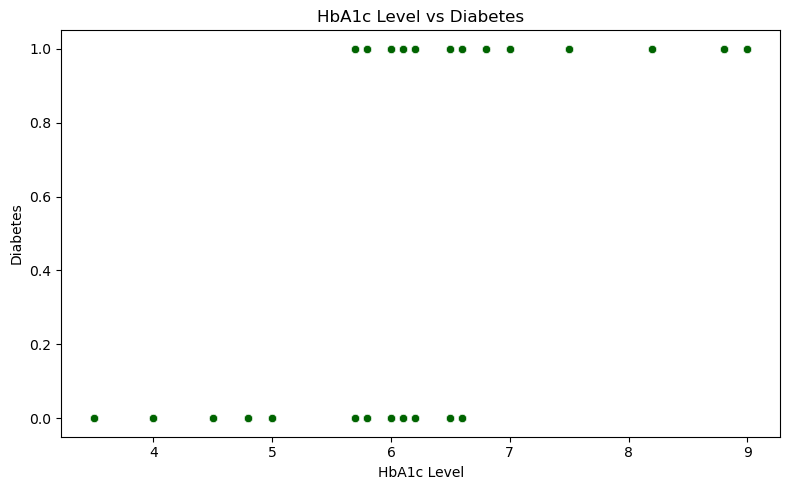

In [19]:
# HbA1c level vs diabetes

plt.figure(figsize=(8, 5))
sns.scatterplot(
    x=df["HbA1c_level"],
    y=df["diabetes"],
    color="darkgreen"
)
plt.title("HbA1c Level vs Diabetes")
plt.xlabel("HbA1c Level")
plt.ylabel("Diabetes")
plt.tight_layout()
plt.show()


### Insight

The scatter plot shows that diabetes-positive observations are more common at higher HbA1c levels. This indicates that HbA1c level has a useful relationship with the target variable.


In [20]:
# Check and treat outliers using the IQR method

outlier_cols = ["bmi", "HbA1c_level", "blood_glucose_level"]
outlier_summary = []
for col in outlier_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    count = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_summary.append({
        "Feature": col,
        "Lower Bound": lower,
        "Upper Bound": upper,
        "Outliers Found": count
    })

    df[col] = df[col].clip(lower=lower, upper=upper)

pd.DataFrame(outlier_summary)

,Feature,Lower Bound,Upper Bound,Outliers Found
0,bmi,14.66375,38.61375,143
1,HbA1c_level,2.70000,8.30000,22
2,blood_glucose_level,11.50000,247.50000,33


## Feature Engineering

The engineered feature combines blood glucose level and HbA1c level because both features describe blood sugar related information. Their interaction may provide additional information for the diabetes classification model.


In [21]:
# Create an engineered feature

df["glucose_hba1c_interaction"] = (df["blood_glucose_level"] * df["HbA1c_level"])


In [22]:
# Separate features and target

x = df.drop("diabetes", axis=1)
y = df["diabetes"]

print("Features:")
print(x.head())
print("\nTarget:")
print(y.head())


Features:
   gender   age  hypertension  heart_disease smoking_history       bmi  \
0  Female  13.0             0              0         No Info  20.82000   
1  Female   3.0             0              0         No Info  21.00000   
2    Male  63.0             0              0          former  25.32000   
3  Female   2.0             0              0           never  17.43000   
4  Female  33.0             0              0     not current  38.61375   

   HbA1c_level  blood_glucose_level  glucose_hba1c_interaction  
0          5.8                126.0                      730.8  
1          5.0                145.0                      725.0  
2          3.5                200.0                      700.0  
3          6.1                126.0                      768.6  
4          6.2                200.0                     1240.0  

Target:
0    0
1    0
2    0
3    0
4    1
Name: diabetes, dtype: int64


In [23]:
# Identify numerical and categorical features

num_features = x.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_features = x.select_dtypes(include=["object", "category"]).columns.tolist()
print("Numerical features:")
print(num_features)
print("\nCategorical features:")
print(cat_features)

Numerical features:
['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'glucose_hba1c_interaction']

Categorical features:
['gender', 'smoking_history']


In [24]:
# Preprocessing

prep = ColumnTransformer(
    transformers=[
        ("numerical", StandardScaler(), num_features),
        ("categorical", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ), cat_features)
    ]
)


In [25]:
# Stratified train-test split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", x_train.shape)
print("Testing set:", x_test.shape)

Training set: (1596, 9)
Testing set: (400, 9)


In [26]:
# Create Support Vector Machine Classifier

svm_model = Pipeline(
    steps=[
        ("preprocessing", prep),
        ("svm", SVC(
            kernel="rbf",
            C=1.0,
            gamma="scale",
            probability=True,
            random_state=42
        ))
    ]
)

svm_model


,steps,"[('preprocessing', ...), ('svm', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numerical', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [27]:
# Train the SVM model

svm_model.fit(x_train, y_train)
print("SVM model trained successfully.")

SVM model trained successfully.


In [28]:
# Make predictions
svm_pred = svm_model.predict(x_test)
svm_prob = svm_model.predict_proba(x_test)[:, 1]

print("Predictions:")
print(svm_pred[:10])

Predictions:
[0 0 0 0 0 0 0 0 0 0]


In [29]:
# Calculate evaluation metrics

svm_accuracy = accuracy_score(y_test, svm_pred)
svm_precision = precision_score(y_test, svm_pred, zero_division=0)
svm_recall = recall_score(y_test, svm_pred, zero_division=0)
svm_f1 = f1_score(y_test, svm_pred, average="weighted")
svm_auc = roc_auc_score(y_test, svm_prob)

print("Support Vector Machine Performance")
print("Accuracy:", round(svm_accuracy, 4))
print("Precision:", round(svm_precision, 4))
print("Recall:", round(svm_recall, 4))
print("Weighted F1:", round(svm_f1, 4))
print("ROC-AUC:", round(svm_auc, 4))


Support Vector Machine Performance
Accuracy: 0.96
Precision: 1.0
Recall: 0.5152
Weighted F1: 0.954
ROC-AUC: 0.926


In [30]:
# Classification report
print("Support Vector Machine Classification Report")
print(
    classification_report(
        y_test,
        svm_pred,
        target_names=["No Diabetes", "Diabetes"],
        zero_division=0
    )
)

Support Vector Machine Classification Report
              precision    recall  f1-score   support

 No Diabetes       0.96      1.00      0.98       367
    Diabetes       1.00      0.52      0.68        33

    accuracy                           0.96       400
   macro avg       0.98      0.76      0.83       400
weighted avg       0.96      0.96      0.95       400



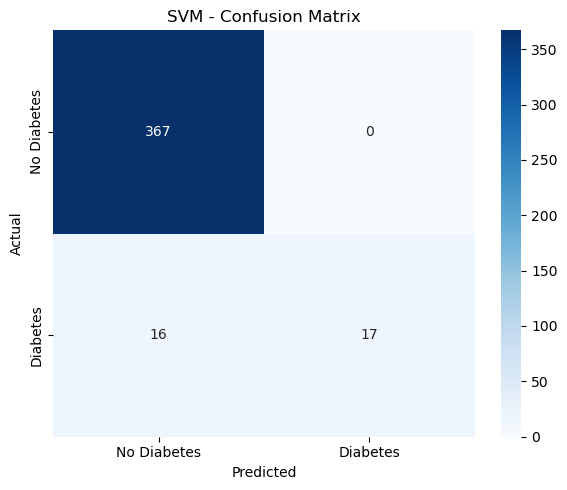

In [31]:
# Confusion Matrix

cm_svm = confusion_matrix(y_test, svm_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Diabetes", "Diabetes"],
    yticklabels=["No Diabetes", "Diabetes"]
)
plt.title("SVM - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


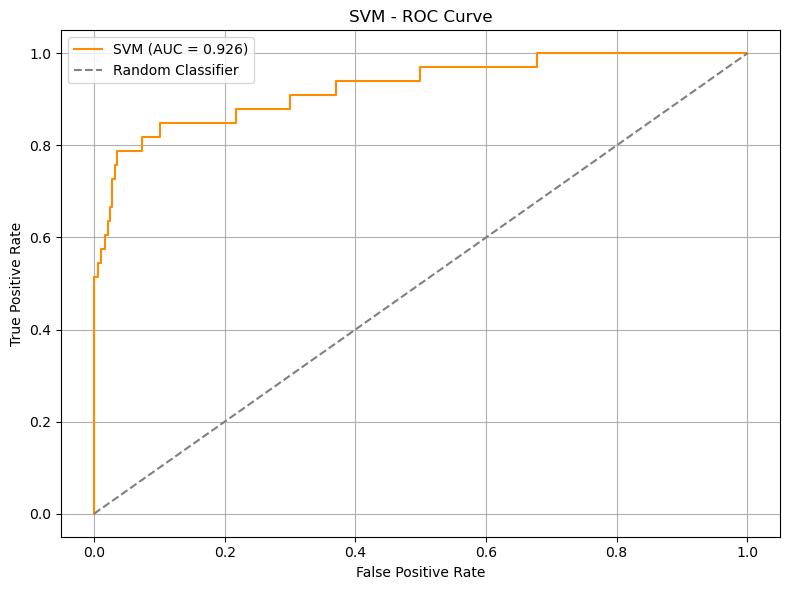

In [32]:
# ROC Curve

svm_fpr, svm_tpr, _ = roc_curve(y_test, svm_prob)
plt.figure(figsize=(8, 6))
plt.plot(
    svm_fpr,
    svm_tpr,
    color="darkorange",
    label=f"SVM (AUC = {svm_auc:.3f})"
)
plt.plot(
    [0, 1],
    [0, 1],
    color="gray",
    linestyle="--",
    label="Random Classifier"
)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("SVM - ROC Curve")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


In [33]:
# Save SVM results

import os
os.makedirs("../results", exist_ok=True)
results_path = "../results/classification_results.csv"
row = pd.DataFrame([{
    "Model": "Support Vector Machine",
    "Accuracy": svm_accuracy,
    "Precision": svm_precision,
    "Recall": svm_recall,
    "Weighted F1": svm_f1,
    "ROC-AUC": svm_auc
}])

if os.path.exists(results_path):
    saved = pd.read_csv(results_path)
    saved = saved[saved["Model"] != "Support Vector Machine"]
    row = pd.concat([saved, row], ignore_index=True)

row.to_csv(results_path, index=False)

os.makedirs("../results/predictions", exist_ok=True)
pd.DataFrame({
    "y_test": y_test.values,
    "y_pred": svm_pred,
    "y_prob": svm_prob
}).to_csv(
    "../results/predictions/Support Vector Machine.csv",
    index=False
)

row.sort_values(
    "Weighted F1",
    ascending=False
).reset_index(drop=True)

,Model,Accuracy,Precision,Recall,Weighted F1,ROC-AUC
0,Decision Tree,0.9625,1.000000,0.545455,0.957361,0.953596
1,Support Vector Machine,0.9600,1.000000,0.515152,0.954027,0.926018
2,K-Nearest Neighbors,0.9550,0.894737,0.515152,0.949363,0.868095
3,Logistic Regression,0.9450,0.789474,0.454545,0.938111,0.943110
4,Gaussian Naive Bayes,0.9000,0.438596,0.757576,0.911643,0.935596


## Final Classification Comparison

The table below combines the results saved by the five classification notebooks. It provides a preliminary comparison using Accuracy, Precision, Recall, Weighted F1, and ROC-AUC.


In [34]:
# Final comparison table
if os.path.exists(results_path):
    comparison = pd.read_csv(results_path)
    comparison.sort_values(
        "Weighted F1",
        ascending=False
    ).reset_index(drop=True)
else:
    comparison = row
comparison

,Model,Accuracy,Precision,Recall,Weighted F1,ROC-AUC
0,Logistic Regression,0.9450,0.789474,0.454545,0.938111,0.943110
1,K-Nearest Neighbors,0.9550,0.894737,0.515152,0.949363,0.868095
2,Gaussian Naive Bayes,0.9000,0.438596,0.757576,0.911643,0.935596
3,Decision Tree,0.9625,1.000000,0.545455,0.957361,0.953596
4,Support Vector Machine,0.9600,1.000000,0.515152,0.954027,0.926018
